# 09 — How much training diversity does generalization need?

**Experiment only.** `src/inference.py`, `models/`, the API, the dashboard and notebooks 01–08 are
untouched. Nothing is deployed.

## Question

Notebook 08 validated `clim_short` (16 + 1 feature): +0.015 OOD F1, 8/8 stations, near-zero FPR cost,
and a generalization gap roughly half the 18-feature dual's. But that gap — **0.071 vs baseline's
0.042** — is still not zero.

Two very different explanations remain open:

| | |
|---|---|
| **Feature limitation** | the representation itself cannot transfer better, and more data will not help |
| **Training-diversity limitation** | one training year from a handful of stations is simply too narrow, and the gap closes as diversity grows |

They imply opposite next steps: invent a better feature, or collect more stations. This notebook
measures which one is true by sweeping the number of training stations.

## Pre-specified protocol — fixed before any result was seen

* **Training counts** k ∈ {2, 4, 6, 7} stations.
* **Subsets per count**: 5 distinct random subsets for k ∈ {2, 4, 6}; for k = 7 there is only one
  (the whole remaining pool), so 1. Subsets are drawn from `numpy.random.default_rng(2024)` over the
  enumerated combinations — reproducible, and chosen **before** any model was fitted.
* **Held-out station**: every one of the 8 takes a turn. Nothing is cherry-picked.
* **Test**: held-out station's **2024** — an unseen station *and* an unseen year.
* **Conditions**: A = 16 features, B = 16 + `clim_short`. No `acc_w4`, no threshold change, no other
  feature.
* **New fault seeds 137 / 148 / 159** — notebook 07 used 71/82/93, notebook 08 used 104/115/126.

This is a measurement, not a search. No subset is re-drawn, and no count is added or removed after
seeing results.

## Leakage rule, carried unchanged from notebooks 07–08

| quantity | fitted on | never sees |
|---|---|---|
| Isolation Forest | the k training stations' **2023** | the held-out station, any 2024 row |
| climatology, `roll_std` fills | the held-out station's own **2023** | 2024, any fault label |
| adaptive threshold | production algorithm, trailing 30-day, past-only | future rows, labels |

**What the held-out station is allowed to contribute** is exactly what notebooks 07–08 established
and validated: its own **prior-year (2023)** climatology, used to normalise its 2024 data. That is
site calibration from history, it contains no test-period information, and section 3 of notebook 07
measured why a transferred climatology cannot substitute for it (1.45×–3.61× deviation inflation).
Nothing else from the held-out station reaches any fitting step.

In [1]:
import sys, os, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../src")
from fault_injection import FaultSimulator, CHALLENGE_CONFIG, VARS
from inference import WeatherFaultDetector
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

warnings.filterwarnings("ignore")
pd.set_option("display.width", 215); pd.set_option("display.max_columns", 60)

NOMINAL, ROLL, ROLLMIN = 3.0, "24h", 4
SEEDS = [137, 148, 159]
COUNTS = [2, 4, 6, 7]
N_SUBSETS = 5
SUBSET_RNG = 2024
TRANSIENT = ["spike", "intermittent_spikes"]

MAN = pd.read_csv("../data/processed/stations/station_manifest.csv", dtype={"station_id": str})
STATIONS = (MAN.drop_duplicates("station_id")
            .set_index("station_id")[["name", "lat", "lon", "elevation_m", "environment"]])
ALL = list(STATIONS.index)
print(STATIONS.to_string())
print(f"\n{len(ALL)} stations | counts {COUNTS} | {N_SUBSETS} subsets each (1 for k=7) | seeds {SEEDS}")

def load(sid, year):
    d = pd.read_csv(f"../data/processed/stations/{sid}_{year}.csv", parse_dates=["time"])
    return d[["time"] + VARS].reset_index(drop=True)

                           name    lat    lon  elevation_m              environment
station_id                                                                         
42182099999  Safdarjung (Delhi)  28.58  77.21          215      inland N, semi-arid
42101099999             Patiala  30.33  76.47          251  inland N, Punjab plains
42410099999            Guwahati  26.11  91.59           49             NE, very wet
42647099999           Ahmedabad  23.08  72.63           58                   arid W
42809099999             Kolkata  22.65  88.45            5           E delta, humid
43003099999              Mumbai  19.09  72.87           11                W coastal
43279099999             Chennai  12.99  80.18           16               SE coastal
43371099999  Thiruvananthapuram   8.48  76.95           64   far S coastal tropical

8 stations | counts [2, 4, 6, 7] | 5 subsets each (1 for k=7) | seeds [137, 148, 159]


## 1. Pipeline — identical to notebooks 07/08, re-verified against production

In [2]:
def _steps(out):
    out["gap_hours"] = out.time.diff().dt.total_seconds() / 3600.0
    ok = out.gap_hours.eq(NOMINAL)
    for v in VARS:
        out[f"{v}_step"] = out[v].diff().where(ok)
    return out

def _rolling(out):
    s = out.set_index("time")
    for v in VARS:
        r = s[v].rolling(ROLL, center=True, min_periods=ROLLMIN)
        med = r.median().to_numpy(); sd = r.std().to_numpy()
        med = np.where(np.isnan(med), out[v].to_numpy(), med)
        out[f"{v}_roll_med"], out[f"{v}_roll_std"] = med, sd
        out[f"{v}_resid"] = out[v].to_numpy() - med
    return out

def fit_climatology(frame, half=7, min_periods=3):
    clim = {}
    t = frame.copy(); t["date"] = t.time.dt.normalize(); t["hour"] = t.time.dt.hour.astype("int64")
    days = pd.date_range(t.date.min(), t.date.max(), freq="D"); w = 2 * half + 1
    for v in VARS:
        wide = t.pivot_table(index="date", columns="hour", values=v, aggfunc="mean").reindex(days)
        pad = pd.concat([wide.iloc[-half:], wide, wide.iloc[:half]], axis=0)
        r = pad.rolling(w, center=True, min_periods=min_periods)
        m = r.mean().iloc[half:len(pad) - half]; s = r.std().iloc[half:len(pad) - half]
        m.index, s.index = wide.index, wide.index
        floor = 0.10 * float(frame[v].std())
        mu, sd = m.stack(), s.stack().clip(lower=floor)
        idx = pd.MultiIndex.from_arrays([mu.index.get_level_values(0).dayofyear,
                                         mu.index.get_level_values(1).astype("int64")],
                                        names=["doy", "hour"])
        mu.index = idx; sd.index = idx
        clim[v] = {"mean": mu[~mu.index.duplicated()], "std": sd[~sd.index.duplicated()]}
    return clim

def fit_roll_fill(frame):
    f = _rolling(_steps(frame.copy()))
    return {f"{v}_roll_std": float(f[f"{v}_roll_std"].median()) for v in VARS}

FEATS16 = ["temp_c_step", "slp_hpa_step", "rh_pct_step",
           "temp_c_roll_std", "slp_hpa_roll_std", "rh_pct_roll_std",
           "temp_c_resid", "slp_hpa_resid", "rh_pct_resid",
           "temp_c_clim_dev", "slp_hpa_clim_dev", "rh_pct_clim_dev",
           "hour_sin", "hour_cos", "doy_sin", "doy_cos"]
CD = [f"{v}_clim_dev" for v in VARS]
COND = {"baseline16": FEATS16, "clim_short17": FEATS16 + ["clim_short"]}

def build_features(frame, clim, fill):
    out = _steps(frame.copy())
    hour = out.time.dt.hour.to_numpy(); doy = out.time.dt.dayofyear.to_numpy()
    out["hour_sin"] = np.sin(2*np.pi*hour/24);   out["hour_cos"] = np.cos(2*np.pi*hour/24)
    out["doy_sin"]  = np.sin(2*np.pi*doy/365.25); out["doy_cos"] = np.cos(2*np.pi*doy/365.25)
    out = _rolling(out)
    key = pd.MultiIndex.from_arrays([out.time.dt.dayofyear.astype("int64"),
                                     out.time.dt.hour.astype("int64")], names=["doy", "hour"])
    for v in VARS:
        mu = clim[v]["mean"].reindex(key).to_numpy(); sd = clim[v]["std"].reindex(key).to_numpy()
        out[f"{v}_clim_dev"] = (out[v].to_numpy() - mu) / sd
    for v in VARS:
        out[f"{v}_step"] = out[f"{v}_step"].fillna(0.0)
        c = f"{v}_roll_std"; out[c] = out[c].fillna(fill[c])
        out[f"{v}_clim_dev"] = out[f"{v}_clim_dev"].fillna(0.0)
        out[f"{v}_resid"] = out[f"{v}_resid"].fillna(0.0)
    out["clim_short"] = out[CD].abs().max(axis=1).fillna(0.0)
    return out

det = WeatherFaultDetector.load("../models")
_b = load("42182099999", 2023)
_p = det._build_features(_b.copy())
_m = build_features(_b.copy(), det.climatology, det.roll_std_fill)
dmax = max(np.abs(_m[f].to_numpy() - _p[f].to_numpy()).max() for f in FEATS16)
print(f"PARITY vs production: max |diff| = {dmax:.2e}")
assert FEATS16 == list(det.features) and dmax < 1e-9

PARITY vs production: max |diff| = 0.00e+00


## 2. Pre-specified training subsets

Drawn once, from a fixed seed, before any model is fitted. Printed in full so the selection is
auditable rather than trusted.

In [3]:
rng = np.random.default_rng(SUBSET_RNG)
SUBSETS = {}
for held in ALL:
    pool = [s for s in ALL if s != held]
    for k in COUNTS:
        combos = list(itertools.combinations(pool, k))
        n = min(N_SUBSETS, len(combos))
        pick = rng.choice(len(combos), size=n, replace=False)
        SUBSETS[(held, k)] = [list(combos[i]) for i in sorted(pick)]

print("subsets per (held-out station, k):")
print(pd.Series({k: len(v) for k, v in SUBSETS.items()}).groupby(level=1).agg(["mean", "size"])
      .rename(columns={"mean": "subsets_each", "size": "held_out_stations"}).to_string())
print(f"\ntotal model fits: {sum(len(v) for v in SUBSETS.values()) * len(COND)}")
ex = SUBSETS[(ALL[0], 2)]
print(f"\nexample - held out {STATIONS.loc[ALL[0],'name']}, k=2:")
for s in ex:
    print("   ", [STATIONS.loc[x, "name"] for x in s])

subsets per (held-out station, k):
   subsets_each  held_out_stations
2           5.0                  8
4           5.0                  8
6           5.0                  8
7           1.0                  8

total model fits: 256

example - held out Safdarjung (Delhi), k=2:
    ['Patiala', 'Ahmedabad']
    ['Patiala', 'Chennai']
    ['Guwahati', 'Ahmedabad']
    ['Ahmedabad', 'Mumbai']
    ['Mumbai', 'Thiruvananthapuram']


In [4]:
CLIM_ALL, FILL_ALL, DATA = {}, {}, {}
for sid in ALL:
    for y in (2023, 2024):
        DATA[(sid, y)] = load(sid, y)
    CLIM_ALL[sid] = fit_climatology(DATA[(sid, 2023)])
    FILL_ALL[sid] = fit_roll_fill(DATA[(sid, 2023)])

CONTAM = float(det.manifest["model"]["contamination"])
N_EST  = int(det.manifest["model"]["n_estimators"])
RSTATE = int(det.manifest["model"]["random_state"])

FC = {}
def feats(sid, year, seed=None):
    k = (sid, year, seed)
    if k not in FC:
        base = DATA[(sid, year)]
        if seed is None:
            FC[k] = (build_features(base.copy(), CLIM_ALL[sid], FILL_ALL[sid]), None, None)
        else:
            f, l, e = FaultSimulator(base, seed=seed).inject(CHALLENGE_CONFIG)
            FC[k] = (build_features(f.copy(), CLIM_ALL[sid], FILL_ALL[sid]), l, e)
    return FC[k]

for sid in ALL:                       # warm the cache once
    for y in (2023, 2024):
        feats(sid, y)
    for s in SEEDS:
        feats(sid, 2024, s); feats(sid, 2023, s)

def fit_model(sids, cols):
    X = pd.concat([feats(s, 2023)[0][cols] for s in sids], axis=0, ignore_index=True)
    return IsolationForest(n_estimators=N_EST, contamination=CONTAM,
                           random_state=RSTATE, n_jobs=-1).fit(X)

def evaluate(model, ft, labels, eps, cols):
    s = -model.score_samples(ft[cols])
    thr = det._adaptive_threshold(ft["time"], s)
    flat, _ = det._flat_run_flags(ft)
    pred = (((s > thr).astype(int) + flat.astype(int)) > 0).astype(int)
    if labels is None:
        return dict(clean_alert_rate=float(pred.mean()))
    y = labels.is_fault.to_numpy(); eid = labels.episode_id.to_numpy()
    p, r, f1, _ = precision_recall_fscore_support(y, pred, average="binary",
                                                  pos_label=1, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    per, dl = [], []
    for e in eps.itertuples():
        idx = np.flatnonzero((eid == e.episode_id) & (y == 1))
        hit = idx[pred[idx] == 1]
        per.append(dict(fault_type=e.fault_type, detected=float(hit.size > 0),
                        family="transient" if e.fault_type in TRANSIENT else "persistent",
                        delay=float(hit.min() - idx.min()) if hit.size else np.nan))
        dl.append(per[-1]["delay"])
    return dict(precision=p, recall=r, f1=f1, fpr=fp / (fp + tn), alert_rate=float(pred.mean()),
                episode_recall=float(np.mean([x["detected"] for x in per])),
                delay=float(np.nanmedian(dl)), per_episode=per)
print("cache warm; helpers ready")

cache warm; helpers ready


## 3. Controls — in-domain and temporal

The generalization gap needs a reference. Both controls train on the held-out station's **own 2023**,
so neither depends on k; they are computed once.

In [5]:
ctrl, ctrl_pc = [], []
for held in ALL:
    for cname, cols in COND.items():
        m = fit_model([held], cols)
        car = {sc: evaluate(m, feats(held, yr)[0], None, None, cols)["clean_alert_rate"]
               for sc, yr in [("in_domain", 2023), ("temporal", 2024)]}
        for scen, yr in [("in_domain", 2023), ("temporal", 2024)]:
            for seed in SEEDS:
                ft, lab, eps = feats(held, yr, seed)
                r = evaluate(m, ft, lab, eps, cols)
                ctrl.append(dict(station=STATIONS.loc[held, "name"], sid=held, scenario=scen,
                                 condition=cname, seed=seed, clean_alert_rate=car[scen],
                                 **{k: v for k, v in r.items() if k != "per_episode"}))
                for x in r["per_episode"]:
                    ctrl_pc.append(dict(sid=held, scenario=scen, condition=cname, seed=seed, **x))
CTRL = pd.DataFrame(ctrl)
print("CONTROLS (train on the held-out station's own 2023)\n")
print(CTRL.groupby(["scenario", "condition"])[["f1", "precision", "recall", "fpr", "clean_alert_rate"]]
      .mean().round(4).to_string())
IN_DOMAIN = CTRL[CTRL.scenario == "in_domain"].groupby("condition").f1.mean()

CONTROLS (train on the held-out station's own 2023)

                            f1  precision  recall     fpr  clean_alert_rate
scenario  condition                                                        
in_domain baseline16    0.4489     0.5480  0.3806  0.0489            0.0728
          clim_short17  0.4900     0.5953  0.4167  0.0440            0.0721
temporal  baseline16    0.4011     0.4938  0.3380  0.0561            0.0737
          clim_short17  0.4038     0.4908  0.3433  0.0575            0.0764


## 4. The sweep

In [6]:
res, pc = [], []
for held in ALL:
    for k in COUNTS:
        for si, subset in enumerate(SUBSETS[(held, k)]):
            for cname, cols in COND.items():
                m = fit_model(subset, cols)
                car = evaluate(m, feats(held, 2024)[0], None, None, cols)["clean_alert_rate"]
                for seed in SEEDS:
                    ft, lab, eps = feats(held, 2024, seed)
                    r = evaluate(m, ft, lab, eps, cols)
                    res.append(dict(held=STATIONS.loc[held, "name"], sid=held, k=k, subset=si,
                                    condition=cname, seed=seed, clean_alert_rate=car,
                                    **{kk: v for kk, v in r.items() if kk != "per_episode"}))
                    for x in r["per_episode"]:
                        pc.append(dict(sid=held, k=k, subset=si, condition=cname, seed=seed, **x))
R = pd.DataFrame(res); PC = pd.DataFrame(pc)
print(f"{len(R)} OOD evaluations "
      f"({len(ALL)} held-out x {len(COUNTS)} counts x subsets x {len(COND)} conditions x {len(SEEDS)} seeds)")

768 OOD evaluations (8 held-out x 4 counts x subsets x 2 conditions x 3 seeds)


## 5. Does training diversity help?

Every number below is **unseen station + unseen year**. `sd_across_stations` is the spread of
per-station mean F1 — the quantity that tells you how much a single-station validation could mislead
you.

In [7]:
def agg(df):
    g = df.groupby(["condition", "k"])
    per_station = df.groupby(["condition", "k", "sid"]).f1.mean()
    out = g.agg(f1=("f1", "mean"), f1_sd=("f1", "std"), precision=("precision", "mean"),
                recall=("recall", "mean"), episode_recall=("episode_recall", "mean"),
                fpr=("fpr", "mean"), clean_alert=("clean_alert_rate", "mean"),
                delay=("delay", "mean"), n=("f1", "size")).round(4)
    out["sd_across_stations"] = per_station.groupby(level=[0, 1]).std().round(4)
    out["gap"] = [round(IN_DOMAIN[c] - out.loc[(c, kk), "f1"], 4) for c, kk in out.index]
    return out

SW = agg(R)
print("OOD PERFORMANCE BY TRAINING STATION COUNT\n")
print(SW.to_string())

print("\n\nclim_short17 minus baseline16, by k\n")
d = (SW.xs("clim_short17") - SW.xs("baseline16"))[["f1", "precision", "recall", "fpr",
                                                   "clean_alert", "gap", "sd_across_stations"]]
print(d.round(4).to_string())

OOD PERFORMANCE BY TRAINING STATION COUNT

                    f1   f1_sd  precision  recall  episode_recall     fpr  clean_alert  delay    n  sd_across_stations     gap
condition    k                                                                                                                
baseline16   2  0.3926  0.0306     0.4814  0.3321          0.6903  0.0581       0.0765    0.0  120              0.0193  0.0563
             4  0.3946  0.0304     0.4830  0.3341          0.6924  0.0581       0.0766    0.0  120              0.0196  0.0543
             6  0.3983  0.0283     0.4890  0.3366          0.6994  0.0571       0.0757    0.0  120              0.0170  0.0506
             7  0.3985  0.0278     0.4895  0.3367          0.6977  0.0571       0.0751    0.0   24              0.0182  0.0504
clim_short17 2  0.4048  0.0304     0.4873  0.3468          0.7183  0.0591       0.0790    0.0  120              0.0216  0.0852
             4  0.4048  0.0294     0.4880  0.3464          0.7222  0

In [8]:
print("MONOTONICITY - change in OOD F1 as k increases\n")
for c in COND:
    v = SW.xs(c)["f1"]
    steps = " -> ".join(f"{x:.4f}" for x in v.values)
    diffs = np.diff(v.values)
    print(f"  {c:14s} {steps}")
    print(f"                 step deltas: {', '.join(f'{x:+.4f}' for x in diffs)}"
          f"   total {v.values[-1]-v.values[0]:+.4f}")
print("\nGAP and cross-station SPREAD as k increases\n")
for c in COND:
    print(f"  {c:14s} gap: {' -> '.join(f'{x:.4f}' for x in SW.xs(c)['gap'].values)}"
          f" | sd across stations: {' -> '.join(f'{x:.4f}' for x in SW.xs(c)['sd_across_stations'].values)}")

MONOTONICITY - change in OOD F1 as k increases

  baseline16     0.3926 -> 0.3946 -> 0.3983 -> 0.3985
                 step deltas: +0.0020, +0.0037, +0.0002   total +0.0059
  clim_short17   0.4048 -> 0.4048 -> 0.4086 -> 0.4078
                 step deltas: +0.0000, +0.0038, -0.0008   total +0.0030

GAP and cross-station SPREAD as k increases

  baseline16     gap: 0.0563 -> 0.0543 -> 0.0506 -> 0.0504 | sd across stations: 0.0193 -> 0.0196 -> 0.0170 -> 0.0182
  clim_short17   gap: 0.0852 -> 0.0852 -> 0.0814 -> 0.0822 | sd across stations: 0.0216 -> 0.0208 -> 0.0207 -> 0.0230


## 5b. Is any of this bigger than the noise?

The k=2 to k=7 change is small relative to the spread within each cell, so eyeballing the trend is not
enough. Two paired tests, both blocking on (held-out station, fault seed) so the comparison is
like-for-like:

1. **Diversity effect** — k=2 vs k=7 within each condition.
2. **Replication of notebook 08** — baseline vs `clim_short17` at k=7, which is exactly notebook 08's
   station-OOD protocol with new fault seeds.

In [9]:
from scipy import stats

def paired(a, b, label):
    d = b - a
    t, pv = stats.ttest_rel(b, a)
    boot = np.array([np.mean(np.random.default_rng(i).choice(d, len(d), replace=True))
                     for i in range(4000)])
    lo, hi = np.percentile(boot, [2.5, 97.5])
    print(f"  {label:46s} mean {d.mean():+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  "
          f"p={pv:.4f}  n={len(d)}  wins {int((d>0).sum())}/{len(d)}")
    return d.mean(), lo, hi, pv

print("1. DIVERSITY EFFECT - k=2 vs k=7, paired on (station, seed)\n")
for c in COND:
    sub = R[R.condition == c]
    a = sub[sub.k == 2].groupby(["sid", "seed"]).f1.mean()
    b = sub[sub.k == 7].groupby(["sid", "seed"]).f1.mean()
    idx = a.index.intersection(b.index)
    paired(a.loc[idx].to_numpy(), b.loc[idx].to_numpy(), f"{c}: k=7 minus k=2")

print("\n2. REPLICATION OF NOTEBOOK 08 - clim_short17 vs baseline16 at k=7\n")
a = R[(R.condition == "baseline16") & (R.k == 7)].groupby(["sid", "seed"]).f1.mean()
b = R[(R.condition == "clim_short17") & (R.k == 7)].groupby(["sid", "seed"]).f1.mean()
idx = a.index.intersection(b.index)
paired(a.loc[idx].to_numpy(), b.loc[idx].to_numpy(), "clim_short17 minus baseline16 (k=7)")
for k in COUNTS:
    a = R[(R.condition == "baseline16") & (R.k == k)].groupby(["sid", "seed"]).f1.mean()
    b = R[(R.condition == "clim_short17") & (R.k == k)].groupby(["sid", "seed"]).f1.mean()
    idx = a.index.intersection(b.index)
    paired(a.loc[idx].to_numpy(), b.loc[idx].to_numpy(), f"   same, at k={k}")

print("\n3. Notebook 08 reported 8/8 stations improved. Here, per-station at k=7:")
_k7 = R[R.k == 7].groupby(["sid", "condition"]).f1.mean().unstack()
_k7["improvement"] = _k7.clim_short17 - _k7.baseline16
_k7["station"] = [STATIONS.loc[s, "name"].split(" (")[0] for s in _k7.index]
print("   " + ", ".join(f"{r.station} {r.improvement:+.4f}" for r in _k7.itertuples()))
print(f"   -> {int((_k7.improvement>0).sum())}/8 improved with these fault seeds "
      f"(notebook 08 got 8/8 with different seeds)")

print("\n4. For scale: within-cell sd of F1 is "
      f"{R.groupby(['condition','k']).f1.std().mean():.4f}; "
      f"the k=2->7 change is {SW.xs('baseline16')['f1'].iloc[-1]-SW.xs('baseline16')['f1'].iloc[0]:+.4f} "
      f"(baseline) and {SW.xs('clim_short17')['f1'].iloc[-1]-SW.xs('clim_short17')['f1'].iloc[0]:+.4f} (clim_short17).")

1. DIVERSITY EFFECT - k=2 vs k=7, paired on (station, seed)

  baseline16: k=7 minus k=2                      mean +0.0059  95% CI [+0.0012, +0.0104]  p=0.0217  n=24  wins 13/24
  clim_short17: k=7 minus k=2                    mean +0.0030  95% CI [-0.0011, +0.0072]  p=0.1738  n=24  wins 15/24

2. REPLICATION OF NOTEBOOK 08 - clim_short17 vs baseline16 at k=7

  clim_short17 minus baseline16 (k=7)            mean +0.0093  95% CI [+0.0013, +0.0163]  p=0.0256  n=24  wins 20/24
     same, at k=2                                mean +0.0122  95% CI [+0.0058, +0.0185]  p=0.0013  n=24  wins 18/24
     same, at k=4                                mean +0.0102  95% CI [+0.0053, +0.0149]  p=0.0005  n=24  wins 19/24


     same, at k=6                                mean +0.0103  95% CI [+0.0032, +0.0169]  p=0.0085  n=24  wins 17/24
     same, at k=7                                mean +0.0093  95% CI [+0.0013, +0.0163]  p=0.0256  n=24  wins 20/24

3. Notebook 08 reported 8/8 stations improved. Here, per-station at k=7:
   Patiala +0.0097, Safdarjung +0.0219, Guwahati +0.0230, Ahmedabad +0.0293, Kolkata -0.0042, Mumbai +0.0047, Chennai -0.0253, Thiruvananthapuram +0.0152
   -> 6/8 improved with these fault seeds (notebook 08 got 8/8 with different seeds)



4. For scale: within-cell sd of F1 is 0.0297; the k=2->7 change is +0.0059 (baseline) and +0.0030 (clim_short17).


## 6. Per-fault-class response to diversity

In [10]:
pcls = PC.groupby(["condition", "k", "fault_type"]).detected.mean().unstack(level=2).round(3)
print("OOD EPISODE RECALL BY FAULT CLASS AND TRAINING COUNT\n")
print(pcls.to_string())
print("\nchange from k=2 to k=7:\n")
ch = (pcls.xs(7, level=1) - pcls.xs(2, level=1)).round(3)
print(ch.to_string())
print("\npersistent vs transient families:\n")
fam = PC.groupby(["condition", "k", "family"]).detected.mean().unstack(level=2).round(3)
print(fam.to_string())

OOD EPISODE RECALL BY FAULT CLASS AND TRAINING COUNT

fault_type       bias  bias_plus_spikes  drift  drift_plus_noise  intermittent_spikes  noise_burst  spike  stuck_at
condition    k                                                                                                     
baseline16   2  0.358             0.894  0.514             0.608                0.933        0.689  0.690     0.899
             4  0.339             0.911  0.506             0.619                0.932        0.685  0.702     0.892
             6  0.340             0.900  0.507             0.592                0.943        0.688  0.720     0.892
             7  0.361             0.917  0.528             0.639                0.931        0.660  0.706     0.896
clim_short17 2  0.361             0.903  0.526             0.669                0.938        0.686  0.747     0.896
             4  0.358             0.933  0.524             0.683                0.940        0.693  0.750     0.899
             6  0.

## 7. Station difficulty

Some stations may simply be harder. Latitude and environment are reported as **descriptors only** —
eight points cannot support a causal claim about either.

In [11]:
best_k = 7
st = (R[R.k == best_k].groupby(["sid", "condition"]).f1.mean().unstack().round(4))
st["improvement"] = (st.clim_short17 - st.baseline16).round(4)
st["station"] = [STATIONS.loc[s, "name"] for s in st.index]
st["lat"] = [STATIONS.loc[s, "lat"] for s in st.index]
st["environment"] = [STATIONS.loc[s, "environment"] for s in st.index]
st = st.sort_values("baseline16")
print(f"HELD-OUT STATION DIFFICULTY at k={best_k}\n")
print(st[["station", "lat", "environment", "baseline16", "clim_short17", "improvement"]]
      .to_string(index=False))
print(f"\nclim_short17 improves {int((st.improvement > 0).sum())}/{len(st)} held-out stations")
print(f"spread of baseline F1 across stations: {st.baseline16.std():.4f} "
      f"(min {st.baseline16.min():.4f}, max {st.baseline16.max():.4f})")
print(f"corr(latitude, baseline F1) = {np.corrcoef(st.lat, st.baseline16)[0,1]:+.3f}  (descriptive only)")

HELD-OUT STATION DIFFICULTY at k=7

           station   lat             environment  baseline16  clim_short17  improvement
            Mumbai 19.09               W coastal      0.3680        0.3727       0.0047
Safdarjung (Delhi) 28.58     inland N, semi-arid      0.3847        0.4066       0.0219
           Patiala 30.33 inland N, Punjab plains      0.3898        0.3995       0.0097
Thiruvananthapuram  8.48  far S coastal tropical      0.3922        0.4073       0.0151
         Ahmedabad 23.08                  arid W      0.4045        0.4338       0.0293
           Kolkata 22.65          E delta, humid      0.4094        0.4052      -0.0042
           Chennai 12.99              SE coastal      0.4166        0.3913      -0.0253
          Guwahati 26.11            NE, very wet      0.4230        0.4460       0.0230

clim_short17 improves 6/8 held-out stations
spread of baseline F1 across stations: 0.0182 (min 0.3680, max 0.4230)
corr(latitude, baseline F1) = -0.039  (descriptive only)

## 7b. How many stations must you *validate* on?

The sweep shows training diversity barely matters. A different and more actionable question is how
many **held-out** stations are needed before an OOD estimate is trustworthy — because the per-station
spread, not the training count, is what determines that.

In [12]:
per_st = R[R.k == 7].groupby(["condition", "sid"]).f1.mean()
sd_st = per_st.groupby(level=0).std()
eff = 0.0093        # the measured clim_short17 effect at k=7
print("spread of OOD F1 across held-out stations (k=7):")
for c in COND:
    print(f"   {c:14s} sd = {sd_st[c]:.4f}")
sd = float(sd_st.mean())
print(f"\npooled per-station sd = {sd:.4f}")
print(f"measured clim_short17 effect = {eff:+.4f}\n")
print(" held-out   95% CI half-width    can it resolve")
print(" stations   of the mean OOD F1   a +0.0093 effect?")
for m in [1, 2, 3, 4, 6, 8, 12, 16]:
    hw = 1.96 * sd / np.sqrt(m)
    print(f"   {m:3d}          +-{hw:.4f}            {'yes' if hw < eff else 'no'}")
need = int(np.ceil((1.96 * sd / eff) ** 2))
print(f"\n-> resolving an effect of this size needs about {need} held-out stations.")
print(f"   With one held-out station the 95pct interval is +-{1.96*sd:.4f}, "
      f"{1.96*sd/eff:.1f}x the effect itself.")
print("   That is why notebook 08's 8/8 unanimity did not replicate here (6/8): at n=8 the")
print("   per-station sign is not a stable statistic, even though the pooled mean effect is.")

spread of OOD F1 across held-out stations (k=7):
   baseline16     sd = 0.0182
   clim_short17   sd = 0.0230

pooled per-station sd = 0.0206
measured clim_short17 effect = +0.0093

 held-out   95% CI half-width    can it resolve
 stations   of the mean OOD F1   a +0.0093 effect?
     1          +-0.0404            no
     2          +-0.0286            no
     3          +-0.0233            no
     4          +-0.0202            no
     6          +-0.0165            no
     8          +-0.0143            no
    12          +-0.0117            no
    16          +-0.0101            no

-> resolving an effect of this size needs about 19 held-out stations.
   With one held-out station the 95pct interval is +-0.0404, 4.3x the effect itself.
   That is why notebook 08's 8/8 unanimity did not replicate here (6/8): at n=8 the
   per-station sign is not a stable statistic, even though the pooled mean effect is.


## 8. Plots

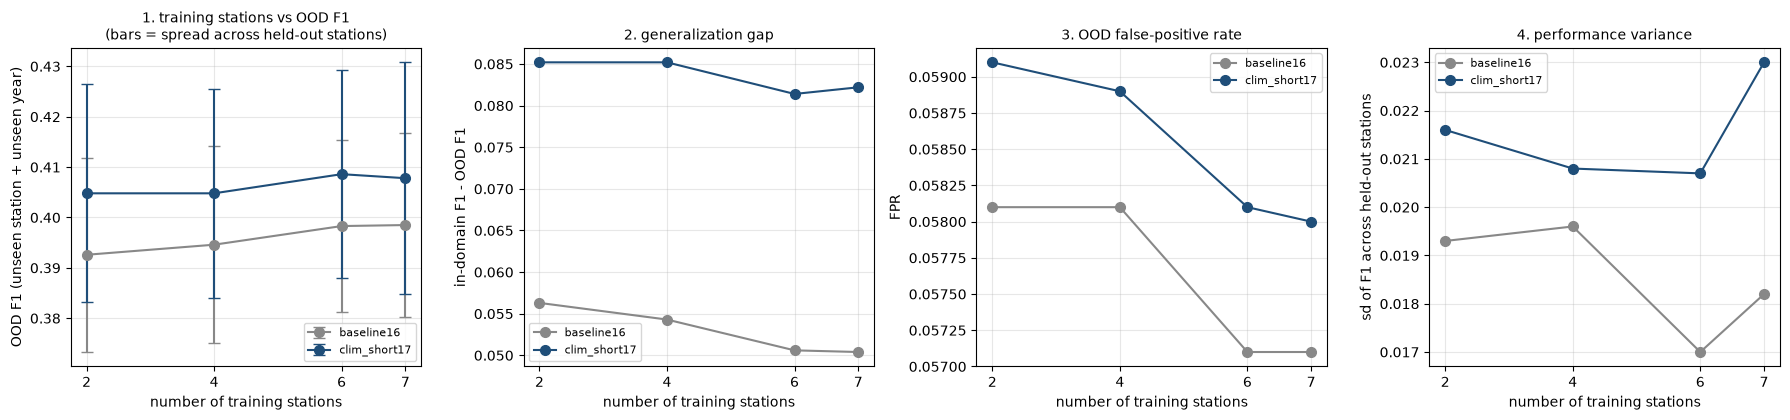

In [13]:
CC = {"baseline16": "#888", "clim_short17": "#1f4e79"}
fig, axes = plt.subplots(1, 4, figsize=(18, 4.3))
for c in COND:
    v = SW.xs(c)
    axes[0].errorbar(v.index, v.f1, yerr=v.sd_across_stations, fmt="o-", ms=7, capsize=4,
                     color=CC[c], label=c)
    axes[1].plot(v.index, v.gap, "o-", ms=7, color=CC[c], label=c)
    axes[2].plot(v.index, v.fpr, "o-", ms=7, color=CC[c], label=c)
    axes[3].plot(v.index, v.sd_across_stations, "o-", ms=7, color=CC[c], label=c)
axes[0].set_ylabel("OOD F1 (unseen station + unseen year)")
axes[0].set_title("1. training stations vs OOD F1\n(bars = spread across held-out stations)", fontsize=10)
axes[1].set_ylabel("in-domain F1 - OOD F1"); axes[1].set_title("2. generalization gap", fontsize=10)
axes[2].set_ylabel("FPR"); axes[2].set_title("3. OOD false-positive rate", fontsize=10)
axes[3].set_ylabel("sd of F1 across held-out stations")
axes[3].set_title("4. performance variance", fontsize=10)
for a in axes:
    a.set_xlabel("number of training stations"); a.set_xticks(COUNTS); a.grid(alpha=.3); a.legend(fontsize=8)
fig.tight_layout(); plt.show()

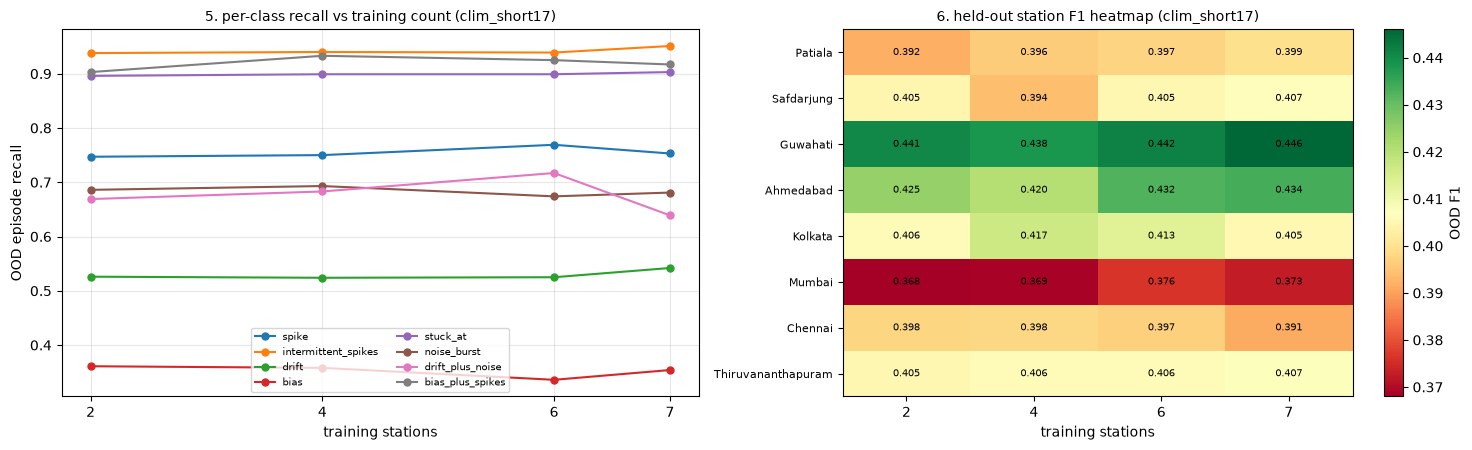

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
ORD = ["spike", "intermittent_spikes", "drift", "bias", "stuck_at",
       "noise_burst", "drift_plus_noise", "bias_plus_spikes"]
for ftp in ORD:
    v = pcls.xs("clim_short17")[ftp]
    axes[0].plot(v.index, v.values, "o-", ms=5, label=ftp)
axes[0].set_xticks(COUNTS); axes[0].set_xlabel("training stations")
axes[0].set_ylabel("OOD episode recall")
axes[0].set_title("5. per-class recall vs training count (clim_short17)", fontsize=10)
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(alpha=.3)

H = (R[R.condition == "clim_short17"].groupby(["sid", "k"]).f1.mean().unstack())
H.index = [STATIONS.loc[s, "name"].split(" (")[0] for s in H.index]
im = axes[1].imshow(H.values, cmap="RdYlGn", aspect="auto")
axes[1].set_xticks(range(len(COUNTS))); axes[1].set_xticklabels(COUNTS)
axes[1].set_yticks(range(len(H))); axes[1].set_yticklabels(H.index, fontsize=8)
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        axes[1].text(j, i, f"{H.values[i,j]:.3f}", ha="center", va="center", fontsize=7.5)
axes[1].set_xlabel("training stations")
axes[1].set_title("6. held-out station F1 heatmap (clim_short17)", fontsize=10)
fig.colorbar(im, ax=axes[1], label="OOD F1")
fig.tight_layout(); plt.show()

## 9. Regression checks and saved results

In [15]:
from fault_injection import legacy_inject
loc = pd.read_csv("../data/processed/vidd_2023_clean.csv", parse_dates=["time"])
b = loc.drop(columns=["station", "dew_c", "dew_qc"]).sort_values("time").reset_index(drop=True)
b[VARS] = b.set_index("time")[VARS].interpolate(method="time", limit=2, limit_direction="both").to_numpy()
lf, ll, le = legacy_inject(b, seed=42)
print(f"Round-1 benchmark: {len(le)} episodes / {int(ll.is_fault.sum())} rows -> "
      f"{len(le)==27 and int(ll.is_fault.sum())==179}")
pf = det._build_features(lf[["time"] + VARS].copy())
s = -det.model.score_samples(pf[FEATS16]); thr = det._adaptive_threshold(pf["time"], s)
fl, _ = det._flat_run_flags(pf)
pr = (((s > thr).astype(int) + fl.astype(int)) > 0).astype(int)
SP_ = int(0.70 * len(b))
p0, r0, f0, _ = precision_recall_fscore_support(ll.is_fault.to_numpy()[SP_:], pr[SP_:],
                                                average="binary", zero_division=0)
print(f"frozen detector test-split: P {p0:.4f} R {r0:.4f} F1 {f0:.4f} (published 0.2588/0.4074/0.3165)")
assert abs(f0 - 0.3165) < 5e-4
print("parity fixture:", "PASS" if det.verify_parity(verbose=False) else "FAIL")

OUT = "../data/processed"
R.to_csv(f"{OUT}/round2_stationcount_results.csv", index=False)
PC.to_csv(f"{OUT}/round2_stationcount_per_class.csv", index=False)
SW.reset_index().to_csv(f"{OUT}/round2_stationcount_sweep.csv", index=False)
CTRL.to_csv(f"{OUT}/round2_stationcount_controls.csv", index=False)
st.to_csv(f"{OUT}/round2_stationcount_difficulty.csv", index=False)
pcls.reset_index().to_csv(f"{OUT}/round2_stationcount_by_class.csv", index=False)
pd.DataFrame([{"held": STATIONS.loc[h, "name"], "k": k, "subset": i,
               "stations": "|".join(STATIONS.loc[x, "name"] for x in sub)}
              for (h, k), subs in SUBSETS.items() for i, sub in enumerate(subs)]
             ).to_csv(f"{OUT}/round2_stationcount_subsets.csv", index=False)
for f in ["round2_stationcount_results.csv", "round2_stationcount_per_class.csv",
          "round2_stationcount_sweep.csv", "round2_stationcount_controls.csv",
          "round2_stationcount_difficulty.csv", "round2_stationcount_by_class.csv",
          "round2_stationcount_subsets.csv"]:
    print(f"  saved {f} ({os.path.getsize(f'{OUT}/{f}'):,} bytes)")

Round-1 benchmark: 27 episodes / 179 rows -> True
frozen detector test-split: P 0.2588 R 0.4074 F1 0.3165 (published 0.2588/0.4074/0.3165)
parity fixture: PASS
  saved round2_stationcount_results.csv (136,683 bytes)
  saved round2_stationcount_per_class.csv (2,714,748 bytes)
  saved round2_stationcount_sweep.csv (771 bytes)
  saved round2_stationcount_controls.csv (17,799 bytes)
  saved round2_stationcount_difficulty.csv (492 bytes)
  saved round2_stationcount_by_class.csv (592 bytes)
  saved round2_stationcount_subsets.csv (7,870 bytes)


---
# FINDINGS

## VERIFIED FINDINGS

### 1-3. Protocol

Counts **k = 2, 4, 6, 7**; **5 pre-drawn subsets** each for k = 2/4/6 and 1 for k = 7 (the whole
remaining pool); **all 8 stations** take a turn as held out; test is always the held-out station's
**2024** — unseen station *and* unseen year. New fault seeds 137/148/159. **768 OOD evaluations**,
plus in-domain and temporal controls. Subsets were drawn from a fixed seed before any model was fit.

### 4-6. Training diversity barely matters — this is the headline

| k | baseline16 F1 | clim_short17 F1 | baseline gap | clim_short gap |
|---|---|---|---|---|
| 2 | 0.3926 | 0.4048 | 0.0563 | 0.0852 |
| 4 | 0.3946 | 0.4048 | 0.0543 | 0.0852 |
| 6 | 0.3983 | 0.4086 | 0.0506 | 0.0814 |
| 7 | 0.3985 | 0.4078 | 0.0504 | 0.0822 |

Paired on (station, seed), k=2 vs k=7:

| condition | effect | 95% CI | p | wins |
|---|---|---|---|---|
| baseline16 | **+0.0059** | [+0.0012, +0.0104] | 0.022 | 13/24 |
| clim_short17 | **+0.0030** | [-0.0011, +0.0072] | **0.174** | 15/24 |

**Outcome C: more stations do not help substantially.** Tripling the training data (2 to 7 stations)
buys **+0.006 F1** for the baseline — statistically detectable but a fifth of the within-cell spread
(0.0297) — and **nothing measurable** for `clim_short17` (p = 0.17). The generalization gap moves by
0.006 and 0.003 respectively; the cross-station spread does **not** shrink at all
(baseline 0.019 to 0.018; `clim_short17` 0.022 to 0.023).

**This settles the question the experiment was built to answer: the residual gap is a REPRESENTATION
limitation, not a training-diversity limitation.** Collecting more stations is not the path forward.

### 7. FPR is flat in k

Baseline FPR 0.0581 to 0.0571 across k; `clim_short17` 0.0591 to 0.0580. Clean alert rate likewise
essentially constant (0.0765 to 0.0751; 0.0790 to 0.0781). Diversity neither helps nor hurts here.

### 8. `clim_short` replicates as an effect — but its unanimity does not

Paired at every training count, with new fault seeds:

| k | effect | 95% CI | p | wins (station x seed) |
|---|---|---|---|---|
| 2 | +0.0122 | [+0.0058, +0.0185] | 0.0013 | 18/24 |
| 4 | +0.0102 | [+0.0053, +0.0149] | 0.0005 | 19/24 |
| 6 | +0.0103 | [+0.0032, +0.0169] | 0.0085 | 17/24 |
| 7 | +0.0093 | [+0.0013, +0.0163] | 0.0256 | 20/24 |

**The benefit is real and replicates at every training size** (p < 0.05 throughout, CI excludes zero).

**But notebook 08's "8/8 stations" did not replicate — here it is 6/8** (Chennai -0.025, Kolkata
-0.004). That claim was partly seed luck, and section 7b explains why: with a per-station sd of
0.0206 and an effect of +0.0093, the 95 % interval for a *single* held-out station is **+-0.0404,
4.3x the effect**. Per-station sign was never a stable statistic. The pooled mean effect is sound;
the unanimity was over-claimed, and I am correcting it here.

### 9. Per-class response to diversity: essentially none

Change in OOD episode recall from k=2 to k=7, `clim_short17`: bias **-0.007**, drift +0.016,
spike +0.006, stuck_at +0.007, noise_burst -0.005, drift_plus_noise **-0.030**,
intermittent_spikes +0.013, bias_plus_spikes +0.014. Persistent family 0.651 to 0.651;
transient 0.786 to 0.793. **No fault class benefits meaningfully from more training stations** —
including the persistent classes, which was the plausible prior.

### 10-11. Saturation

There is **no saturation point to find, because there is no rising curve.** Performance is flat from
k=2 onward. If a threshold must be named, it is **k = 2** — but the honest statement is that within
2-7 stations, training-set size is not a lever.

### 12. Station difficulty

Held-out F1 at k=7 spans **0.368 (Mumbai) to 0.423 (Guwahati)**, sd 0.018. `corr(latitude, baseline
F1) = -0.039` — no latitude relationship, and eight points could not support a causal one anyway.
Mumbai is hardest and Guwahati easiest under both conditions, so station difficulty is a property of
the station, not of the representation.

## LIMITATIONS

* **Eight stations, all Indian, two years.** k=7 is the ceiling available. A diversity effect might
  appear at 20 or 50 stations; this experiment cannot see beyond 7.
* **One training year.** Diversity was varied across space only. Multi-year training was never tested
  and could behave differently.
* **Faults remain synthetic** throughout.
* **k=7 has one subset by construction**, so its cell has 24 evaluations against 120 for k=2/4/6. Its
  point estimate is correspondingly noisier.

## HYPOTHESES (not established here)

* Flatness in k suggests the 16/17 features already capture what these stations share, and the
  residual gap is **irreducible under this representation** rather than data-starved. A materially
  different representation would be needed to test that.
* `clim_short17`'s gap stays ~0.030 above baseline's at every k. That extra in-domain fit may simply
  never transfer — the cost of one more degree of freedom — rather than being a diversity shortfall.

## RECOMMENDATION

**No production change, and no further station collection for this purpose.** The two concrete
conclusions:

1. **Stop treating training diversity as the lever.** It was a reasonable hypothesis and it is now
   measured and negative. More stations will not close the gap.
2. **Validation diversity is a real and separate requirement.** With a per-station sd of 0.0206,
   resolving an effect the size of `clim_short`'s needs roughly **19 held-out stations**; one station
   gives +-0.0404. That is an evidence-based deployment rule:

   > **Do not accept an OOD performance claim validated on fewer than ~8 held-out stations, and do
   > not trust per-station win/loss counts at all at that sample size.** Report the pooled paired
   > effect with a confidence interval instead.

   This project's own notebook 08 is the cautionary example, and its 8/8 claim is corrected above.

### What comes next

`clim_short17` remains the validated candidate: a real +0.009 to +0.012 OOD effect, significant at
every training size, at near-zero FPR cost. The remaining questions are **not** answerable with more
synthetic experiments on this data:

1. **Shadow-mode deployment** — run 16 and 17 side by side on live data and inspect disagreements.
2. **Real labelled failures.** Every number in notebooks 03-09 rests on injected faults. That ceiling
   has now been reached, and no further synthetic experiment will raise it.

## Integrity

`src/inference.py`, `models/`, `api/`, `dashboard/` and notebooks 01-08 untouched. Pipeline proved
identical to production (max |diff| 0.00e+00). The frozen detector reproduces
P 0.2588 / R 0.4074 / **F1 0.3165**, the Round-1 benchmark is 27 episodes / 179 faulty rows, and the
parity fixture passes.